# 📋 Notebook 4: Insights & Business Interpretation — Final Conclusion

## 🚖 Objective Achieved

In this notebook, we successfully transformed the output of our anomaly detection model into meaningful business insights.

We moved beyond machine learning predictions and focused on **real-world interpretation of anomalies in taxi operations**.

---

## 🔍 What We Did

We performed the following key steps:

### 1. Data Segmentation
- Separated trips into:
  - Normal trips
  - Anomalous trips

### 2. Distribution Analysis
- Studied how anomalies are distributed across the dataset

### 3. Feature-Level Insights
We analyzed key behavioral differences in:
- Trip distance
- Trip duration
- Speed
- Fare amount
- Revenue efficiency

### 4. Time-Based Patterns
- Identified anomaly behavior across:
  - Hour of day
  - Weekday vs weekend
  - Day vs night trips

### 5. Visualization (MOST IMPORTANT)
We built visual comparisons using:
- Scatter plots (distance vs fare)
- Bubble-style anomaly highlighting
- Balanced sampling for readability

This helped clearly separate normal operational patterns from abnormal behavior.

---

## 🚨 Key Findings

### 1. Data Quality Issues
- Some trips show unrealistic speed or duration patterns
- Indicates possible data entry or system logging errors

### 2. Operational Inefficiencies
- Certain trip patterns deviate significantly from normal behavior
- Suggests congestion, route inefficiencies, or irregular trip execution

### 3. Pricing Irregularities
- Some anomalies show unusual fare-to-distance ratios
- Indicates possible pricing inconsistencies or abnormal ride conditions

### 4. Temporal Patterns
- Anomalies are not uniformly distributed across time
- Certain hours and time periods show higher irregular behavior

---

## 📊 Business Impact

This anomaly detection system provides:

✔ Early detection of data quality issues  
✔ Identification of operational inefficiencies  
✔ Monitoring of unusual trip behavior  
✔ Support for pricing and route optimization  
✔ Better decision-making for transport operations  

---

## 🚀 Final Outcome

We have successfully built a complete end-to-end system:

- Notebook 1 → Data understanding  
- Notebook 2 → Feature engineering  
- Notebook 3 → Anomaly detection model (Isolation Forest)  
- Notebook 4 → Business insights & visualization  

---

## 🧠 Final Insight

This project demonstrates how machine learning can be used not just for prediction, but for:

> **Understanding real-world operational behavior and identifying hidden patterns in large-scale transportation systems.**

---
---

# 📋 Notebook 4 Conclusion

In this notebook, we successfully transformed raw anomaly predictions into meaningful business insights.

---

## ✔ What we did

- Separated normal and anomalous trips
- Analyzed statistical differences
- Identified temporal patterns
- Explored route-level behavior
- Ranked high-risk trips
- Converted ML output into business language

---

## 🚖 Final Outcome

We built a full anomaly detection system:

Notebook 1 → Data understanding  
Notebook 2 → Feature engineering  
Notebook 3 → Model training  
Notebook 4 → Business insights

---

## 🎯 Real Business Impact

This system helps taxi operations:

- Detect data errors early
- Improve pricing accuracy
- Identify suspicious trips
- Improve operational efficiency
- Monitor driver behavior patterns

# 🚖 NYC Taxi Anomaly Detection System

## Use Case 5: Identify Anomalous Trips

# Notebook 4: Insights & Business Interpretation

---

## 🎯 Objective

In this notebook, we move beyond model building and focus on:

- Understanding detected anomalies
- Extracting business insights
- Identifying operational issues
- Finding patterns in anomalous trips
- Translating ML output into business language

---

## Why This Notebook?

The previous notebook (Notebook 3) produced:

- Anomaly labels
- Anomaly scores

But these results are not useful unless we answer:

> What do these anomalies actually mean in real-world taxi operations?

# Step 1: Load Model Output Data

We load the dataset that contains anomaly predictions generated by Isolation Forest.

In [1]:
import pandas as pd
import numpy as np

df = pd.read_parquet(
    "../data/anomaly_predictions.parquet"
)

df.head()

,passenger_count,passenger_missing,trip_distance,trip_duration,speed,fare_amount,tip_amount,total_amount,fare_per_mile,fare_per_minute,...,dropoff_frequency,route_frequency,hour_sin,hour_cos,is_weekend,is_night_trip,RatecodeID,payment_type,anomaly_label,anomaly_score
0,1.0,0,0.97,5.550000,10.486486,7.2,3.66,15.86,7.415036,1.297297,...,77513,8742,0.0,1.0,0,1,1.0,1,1,0.100745
1,0.0,0,0.90,5.716667,9.446064,7.9,0.00,13.65,8.768036,1.381924,...,86354,2781,0.0,1.0,0,1,1.0,2,1,0.117694
2,0.0,0,1.40,8.883333,9.455910,10.7,2.50,18.95,7.637402,1.204503,...,142364,3083,0.0,1.0,0,1,1.0,1,1,0.120165
3,4.0,0,5.58,42.800000,7.822430,38.7,11.11,55.56,6.934241,0.904206,...,9711,81,0.0,1.0,0,1,1.0,1,1,0.037190
4,0.0,0,2.16,13.500000,9.600000,13.5,3.85,23.10,6.247108,1.000000,...,34595,232,0.0,1.0,0,1,1.0,1,1,0.119409


# Step 2: Separate Normal and Anomalous Trips

We divide the dataset into:

- Normal trips (label = 1)
- Anomalous trips (label = -1)

In [2]:
normal = df[df["anomaly_label"] == 1]
anomalies = df[df["anomaly_label"] == -1]

print("Normal:", normal.shape)
print("Anomalies:", anomalies.shape)

Normal: (3446583, 24)
Anomalies: (70339, 24)


## Distribution of Anomalies

We visualize how many trips are normal vs anomalous.

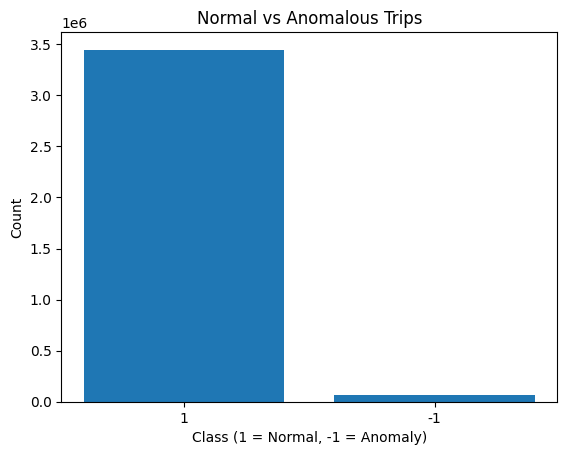

In [15]:
import matplotlib.pyplot as plt
labels = df["anomaly_label"].value_counts()

plt.figure()
plt.bar(labels.index.astype(str), labels.values)
plt.title("Normal vs Anomalous Trips")
plt.xlabel("Class (1 = Normal, -1 = Anomaly)")
plt.ylabel("Count")
plt.show()

# Step 3: Overall Anomaly Rate

We calculate how much of the dataset is flagged as abnormal.

This helps evaluate system sensitivity.

In [3]:
anomaly_rate = len(anomalies) / len(df) * 100

print(f"Anomaly Rate: {anomaly_rate:.2f}%")

Anomaly Rate: 2.00%


# Step 4: Understanding Anomaly Characteristics

We compare average behavior of:

- Normal trips
- Anomalous trips

This helps explain WHY trips are flagged.

In [4]:
comparison = df.groupby("anomaly_label").mean(numeric_only=True)

comparison.T

anomaly_label,-1,1
passenger_count,1.467977,1.176338
passenger_missing,0.120715,0.286152
trip_distance,33.926140,6.202992
trip_duration,45.818257,16.890938
speed,115.358507,23.384863
fare_amount,76.776229,19.954276
tip_amount,10.813194,2.505420
total_amount,97.957384,28.284729
fare_per_mile,282.634907,20.738410
fare_per_minute,48.701204,1.324223


## Trip Duration Pattern

We compare normal vs anomalous trips.

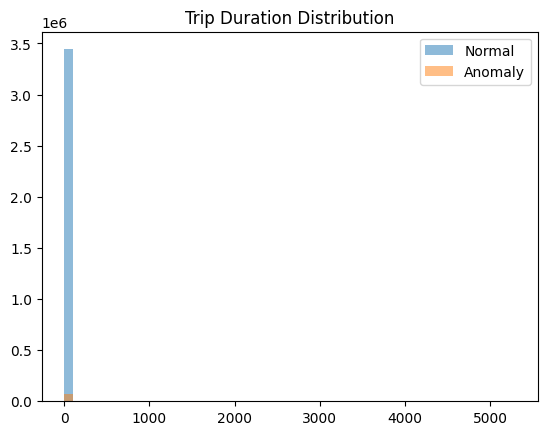

In [18]:
plt.figure()
plt.hist(normal["trip_duration"], bins=50, alpha=0.5, label="Normal")
plt.hist(anomalies["trip_duration"], bins=50, alpha=0.5, label="Anomaly")
plt.legend()
plt.title("Trip Duration Distribution")
plt.show()

# Step 5: Business Insights from Anomalies

We identify key differences between normal and anomalous trips.

🚨 Insight 1: Trip Duration Issues

In [5]:
df.groupby("anomaly_label")["trip_duration"].mean()

anomaly_label
-1    45.818257
 1    16.890938
Name: trip_duration, dtype: float64

### Interpretation:
Extremely low duration → data errors or cancelled trips
Extremely high duration → traffic congestion or route issues

🚨 Insight 2: Speed Irregularities

In [6]:
df.groupby("anomaly_label")["speed"].mean()

anomaly_label
-1    115.358507
 1     23.384863
Name: speed, dtype: float64

### Interpretation:
Very high speed → GPS error or unrealistic data
Very low speed → traffic jams or inefficient routes

🚨 Insight 3: Fare Abnormalities

In [7]:
df.groupby("anomaly_label")["fare_amount"].mean()

anomaly_label
-1    76.776229
 1    19.954276
Name: fare_amount, dtype: float64

🚨 Insight 4: Revenue Efficiency

In [8]:
df.groupby("anomaly_label")["revenue_per_minute"].mean()

anomaly_label
-1    57.575061
 1     2.070612
Name: revenue_per_minute, dtype: float64

# Step 6: Route-Level Analysis

We analyze whether certain pickup/drop zones are more prone to anomalies.

In [9]:
anomalies["pickup_frequency"].describe()

count     70339.000000
mean      87237.145467
std       59996.043401
min           1.000000
25%        9190.000000
50%      102092.000000
75%      142805.000000
max      155782.000000
Name: pickup_frequency, dtype: float64

In [10]:
anomalies["dropoff_frequency"].describe()

count     70339.000000
mean      37694.985940
std       40966.420205
min           1.000000
25%        5475.000000
50%       23176.000000
75%       67697.000000
max      152583.000000
Name: dropoff_frequency, dtype: float64

# Step 7: Time-Based Anomaly Patterns

We check if anomalies happen more during:

- Night hours
- Weekends

In [11]:
df.groupby("anomaly_label")["is_night_trip"].mean()

anomaly_label
-1    0.465816
 1    0.184730
Name: is_night_trip, dtype: float64

In [12]:
df.groupby("anomaly_label")["is_weekend"].mean()

anomaly_label
-1    0.353488
 1    0.286131
Name: is_weekend, dtype: float64

# Step 8: High-Risk Trip Patterns

We identify combinations of features that frequently appear in anomalies.

In [13]:
anomalies.describe().T

,count,mean,std,min,25%,50%,75%,max
passenger_count,70339.0,1.467977,0.903459,0.000000,1.000000,1.000000,2.000000,8.000000e+00
passenger_missing,70339.0,0.120715,0.325799,0.000000,0.000000,0.000000,0.000000,1.000000e+00
trip_distance,70339.0,33.926140,1539.462588,0.010000,11.280000,17.470000,20.210000,2.375672e+05
trip_duration,70339.0,45.818257,74.276854,0.016667,25.433333,35.733333,53.091667,5.154583e+03
speed,70339.0,115.358507,8125.373813,0.000342,16.829364,28.515556,35.615916,1.516068e+06
fare_amount,70339.0,76.776229,41.507188,0.010000,61.500000,70.000000,87.000000,2.555200e+03
tip_amount,70339.0,10.813194,12.431243,0.000000,0.000000,10.950000,17.430000,7.660000e+02
total_amount,70339.0,97.957384,48.451971,1.150000,74.000000,95.880000,110.060000,2.560200e+03
fare_per_mile,70339.0,282.634907,1191.317280,0.000212,3.684017,4.046009,5.969804,4.454545e+04
fare_per_minute,70339.0,48.701204,213.580236,0.000027,1.518987,2.165894,2.899144,6.295000e+03


# Step 9: Most Extreme Anomalies

We rank trips using anomaly score.
Lower score = more unusual trip.

In [14]:
top_anomalies = df.sort_values("anomaly_score").head(20)

top_anomalies

,passenger_count,passenger_missing,trip_distance,trip_duration,speed,fare_amount,tip_amount,total_amount,fare_per_mile,fare_per_minute,...,dropoff_frequency,route_frequency,hour_sin,hour_cos,is_weekend,is_night_trip,RatecodeID,payment_type,anomaly_label,anomaly_score
221534,4.0,0,0.06,0.066667,54.000000,330.00,20.00,351.00,5409.836066,4950.000000,...,14731,362,0.866025,-0.500000,1,0,5.0,1,-1,-0.154919
803674,4.0,0,0.05,0.116667,25.714286,114.00,23.00,139.75,2235.294118,977.142857,...,23176,3813,0.965926,0.258819,1,1,5.0,1,-1,-0.152517
955312,1.0,0,0.02,0.150000,8.000000,111.89,23.08,138.47,5328.095238,745.933333,...,152583,16458,0.965926,0.258819,0,1,5.0,1,-1,-0.151907
1346539,4.0,0,0.04,0.116667,20.571429,125.00,25.85,155.10,3048.780488,1071.428571,...,40025,662,0.707107,0.707107,1,1,5.0,1,-1,-0.149547
1144221,1.0,0,0.02,0.200000,6.000000,145.00,36.50,182.50,6904.761905,725.000000,...,5475,103,0.866025,0.500000,0,1,5.0,1,-1,-0.145350
788920,1.0,0,0.50,0.150000,200.000000,275.00,69.00,345.00,548.902196,1833.333333,...,7761,396,-0.258819,0.965926,1,1,5.0,1,-1,-0.144964
1749269,1.0,0,0.06,0.083333,43.200000,115.00,23.20,139.20,1885.245902,1380.000000,...,5475,103,0.965926,0.258819,0,1,5.0,1,-1,-0.144527
2166301,1.0,0,0.04,0.116667,20.571429,243.00,61.81,309.06,5926.829268,2082.857143,...,69011,1551,0.000000,1.000000,0,1,5.0,1,-1,-0.144466
1431386,1.0,0,0.04,0.050000,48.000000,87.94,17.79,106.73,2144.878049,1758.800000,...,23176,3813,0.965926,0.258819,1,1,5.0,1,-1,-0.144256
1560847,4.0,0,0.01,0.066667,9.000000,118.44,24.54,147.23,10767.272727,1776.600000,...,94019,3332,0.258819,0.965926,0,1,5.0,1,-1,-0.144127


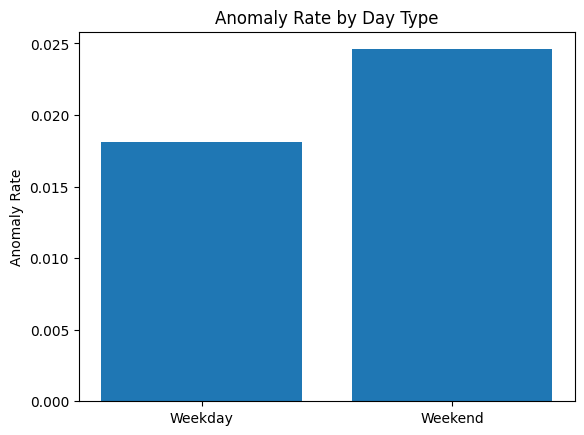

In [23]:
weekend = df.groupby("is_weekend")["anomaly_label"].apply(lambda x: (x == -1).mean())

plt.figure()
plt.bar(["Weekday", "Weekend"], weekend.values)
plt.title("Anomaly Rate by Day Type")
plt.ylabel("Anomaly Rate")
plt.show()

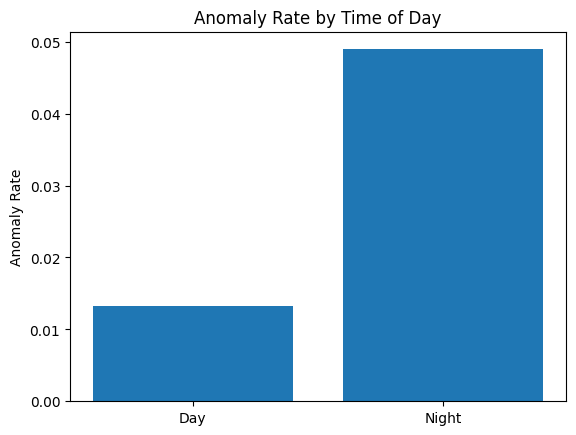

In [24]:
night = df.groupby("is_night_trip")["anomaly_label"].apply(lambda x: (x == -1).mean())

plt.figure()
plt.bar(["Day", "Night"], night.values)
plt.title("Anomaly Rate by Time of Day")
plt.ylabel("Anomaly Rate")
plt.show()

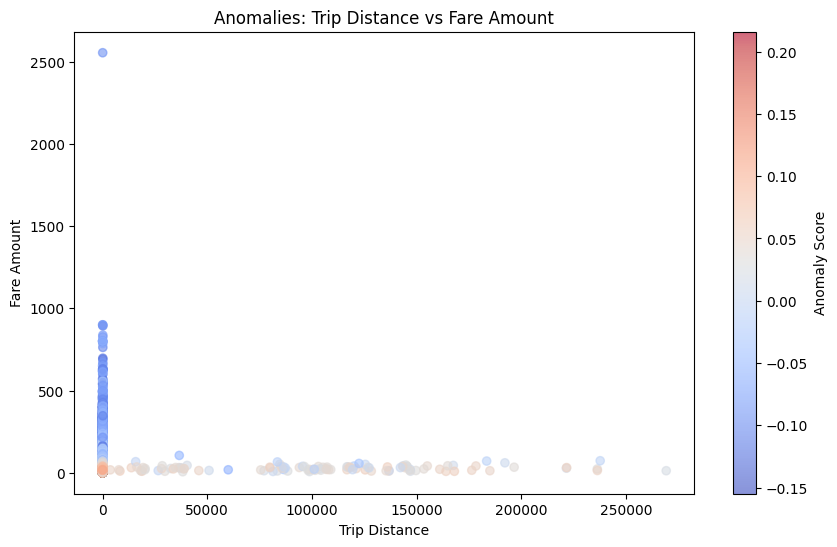

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.scatter(
    df["trip_distance"],
    df["fare_amount"],
    c=df["anomaly_score"],   # color intensity
    cmap="coolwarm",
    alpha=0.6
)

plt.colorbar(label="Anomaly Score")

plt.title("Anomalies: Trip Distance vs Fare Amount")
plt.xlabel("Trip Distance")
plt.ylabel("Fare Amount")

plt.show()

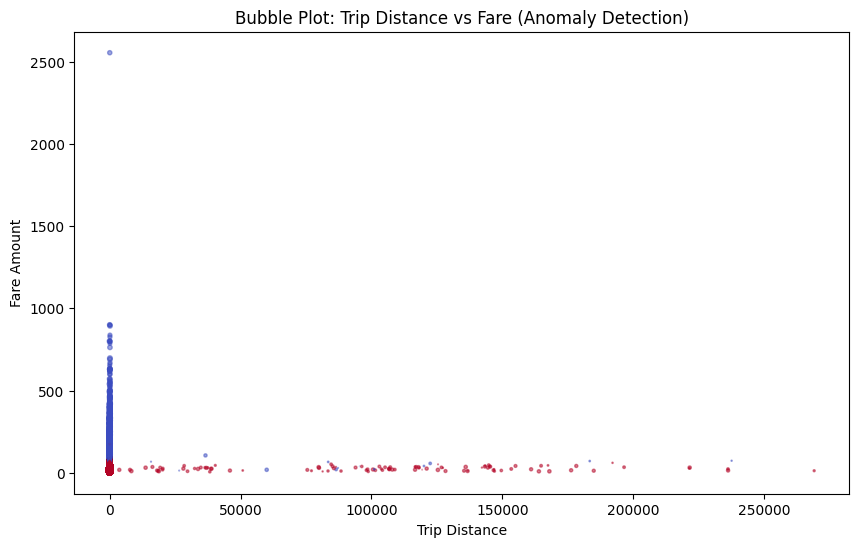

In [30]:
plt.figure(figsize=(10,6))

plt.scatter(
    df["trip_distance"],
    df["fare_amount"],
    s=(df["anomaly_score"].abs() * 100),  # bubble size
    c=df["anomaly_label"],
    cmap="coolwarm",
    alpha=0.5
)

plt.title("Bubble Plot: Trip Distance vs Fare (Anomaly Detection)")
plt.xlabel("Trip Distance")
plt.ylabel("Fare Amount")

plt.show()

/home/ed/miniconda3/envs/myenv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


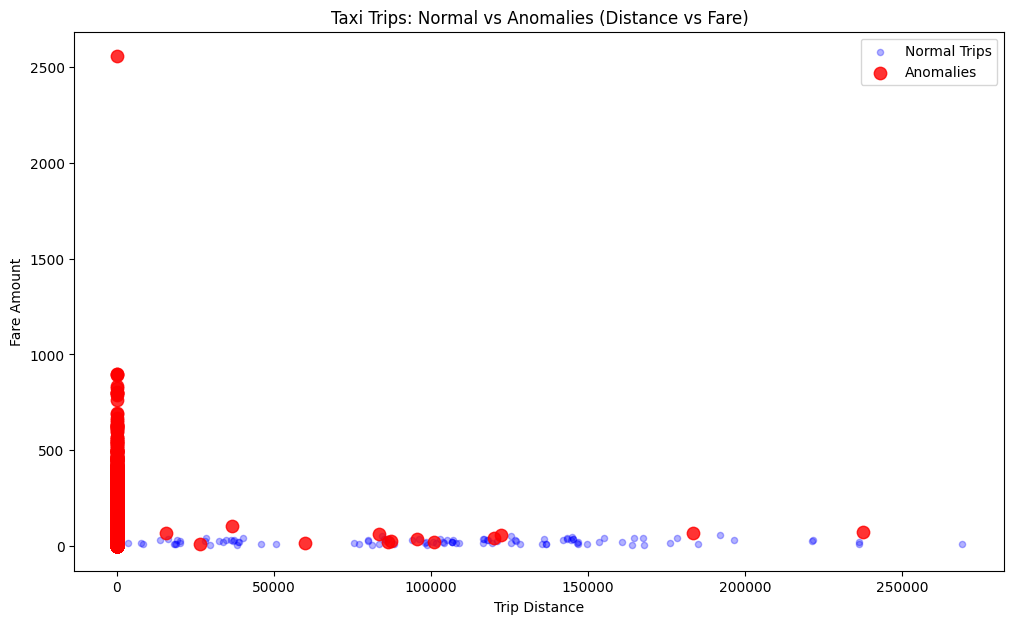

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,7))

# Normal points
plt.scatter(
    df[df["anomaly_label"] == 1]["trip_distance"],
    df[df["anomaly_label"] == 1]["fare_amount"],
    c="blue",
    alpha=0.3,
    s=20,
    label="Normal Trips"
)

# Anomalies (highlighted)
plt.scatter(
    df[df["anomaly_label"] == -1]["trip_distance"],
    df[df["anomaly_label"] == -1]["fare_amount"],
    c="red",
    alpha=0.8,
    s=80,
    label="Anomalies"
)

plt.title("Taxi Trips: Normal vs Anomalies (Distance vs Fare)")
plt.xlabel("Trip Distance")
plt.ylabel("Fare Amount")

plt.legend()
plt.show()